In [2]:
from rdkit import Chem

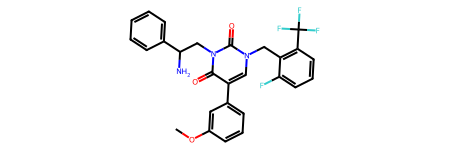

In [13]:
Chem.MolFromSmiles('COC1=CC(C2=CN(CC3=C(C(F)(F)F)C=CC=C3F)C(=O)N(CC(N)C3=CC=CC=C3)C2=O)=CC=C1')

In [13]:
from rdkit import Chem
from rdkit.Chem import rdFMCS

# Example molecules (Benzene ring with different tails)
smiles_list = ["c1ccccc1CC", "c1ccccc1CO", "c1ccccc1CN"]
mols = [Chem.MolFromSmiles(s) for s in smiles_list]

# 1. Run the MCS algorithm
# maximizeBonds=True usually gives cleaner substructures
res = rdFMCS.FindMCS(mols, maximizeBonds=True) 

# 2. Convert the result SMARTS to a Query Molecule
mcs_query = Chem.MolFromSmarts(res.smartsString)

# 3. Find where this MCS exists in the FIRST molecule of your list
# (Since it's a common substructure, it fits into any of them)
match_atoms = mols[0].GetSubstructMatch(mcs_query)

# 4. Extract those specific atoms from the real molecule to generate the SMILES
# This ensures you get "C" and "N" instead of SMARTS queries
mcs_smiles = Chem.MolFragmentToSmiles(
    mols[0], 
    atomsToUse=match_atoms, 
    canonical=True, 
    isomericSmiles=False # Set True if you need chirality
)

print(f"Raw SMARTS: {res.smartsString}")
print(f"Clean SMILES: {mcs_smiles}")

Raw SMARTS: [#6]1:[#6]:[#6]:[#6]:[#6]:[#6]:1-[#6]
Clean SMILES: Cc1ccccc1
